# Temas Tratados en el Trabajo Práctico 5

* Comportamiento y operaciones bajo incertidumbre.

* Teorema de Bayes.

* Representación de la información incierta en Redes Bayesianas.

* Inferencia por enumeración.

* Redes de Markov y matrices de transición.

* Tiempo esperado y probabilidad de absorción.


## Ejercicios Teóricos

1. ¿Cuáles son los tres axiomas de Kolmogorov?


2. Una fábrica de clavos dispone de 2 máquinas que elaboran el 30% y 70% de los clavos que producen respectivamente. El porcentaje de clavos defectuosos de cada máquina es del 2% y 3%, respectivamente. Si se selecciona al azar un clavo de la producción y este fue defectuoso, ¿cuál es la probabilidad de que haya sido fabricado por la máquina?

3. La probabilidad de que un motor que sale de una fábrica con una *avería eléctrica* es de $10^{-3}$, y la probabilidad de que salga con una *avería mecánica* es de $10^{-5}$. Si existe un tipo de avería no se producen averías del otro tipo.
<br><br>Si el motor presenta *temperatura elevada* se enciende un *piloto luminoso* el 95% de las veces, cuando la *temperatura es reducida* el *piloto luminoso* se enciende el 99% de las veces, y a veces cuando la *temperatura se encuentra en un rango normal* el *piloto luminoso* se enciende erróneamente en un caso por millón.
<br><br>Cuando *no hay averías*, la *temperatura se eleva* en el 17% de los casos y es *reducida* el 5% de las veces. Si hay una *avería eléctrica*, la *temperatura se eleva* en el 90% de los casos y es *reducida* en el 1% de los casos. Finalmente cuando la *avería es mecánica*, la *temperatura está elevada* el 10% de los casos y *reducida* el 40% de las veces.
<br><br>Construya una Red Bayesiana y utilice inferencia por enumeración para calcular:

        3.1 La probabilidad de que el motor tenga una avería mecánica si se enciende el piloto.

        3.2 La probabilidad de que el motor tenga una avería mecánica si se enciende el piloto y la temperatura es elevada.

4. Cada día se procesa un producto en secuencia en dos máquinas, M1 y M2. Una inspección se realiza después de que una unidad del producto se completa en cualquiera de las máquinas. 
<br><br>Hay un 5% de probabilidades de que una unidad sea desechada antes de inspeccionarla. Después de la inspección, hay un 3% de probabilidades de que la unidad sea desechada y un 7% de probabilidades de ser devuelta a la misma máquina para trabajarla
de nuevo. Si una unidad pasa la inspección en ambas máquinas es
buena.

        4.1 Dibuje la cadena de Markov que representa este problema y describa para cada estado si es transitorio, recurrente, o absorbente.

        4.2 Arme la matriz de transición

        4.3 Calcule la probabilidad de que una pieza que inicia el proceso en la máquina M1 sea desechada.

        4.4 Calcule la probabilidad de que una pieza de la máquina M2 sea terminada.

        4.5 Si los tiempos de procesamiento en las máquinas M1 y M2 son respectivamente de 20 y 30 minutos y los tiempos de inspección son respectivamente de 5 y 7 minutos, ¿cuánto tiempo tarda en ser procesada una pieza que inicia en la máquina M1?

Promp utilizado: 
Actúa como un experto en probabilidad y sistemas estocásticos. Necesito que resuelvas el siguiente problema de modelado de líneas de producción.

Para esta resolución, es obligatorio que cumplas con los siguientes criterios analíticos:
* **Prioriza el "Por qué":** Antes de calcular, explica el principio físico y la lógica matemática que justifica el uso de Cadenas de Markov Absorbentes para este sistema. Analiza cómo los lazos de retroalimentación afectan el comportamiento global.
* **Desarrollo paso a paso:** Muestra explícitamente cómo construyes la matriz de transición en su forma canónica. Si utilizas fórmulas auxiliares (como el cálculo de la Matriz Fundamental o la matriz de probabilidades de absorción), explica qué representa conceptualmente esa ecuación en la dinámica de la planta antes de mostrar los números.
* **Rigor técnico:** Utiliza terminología profesional de ingeniería. No simplifiques en exceso las explicaciones teóricas ni los pasos algebraicos. Trata esto como un análisis riguroso de fiabilidad.
* **Formato:** Entrega toda la respuesta en código Markdown limpio, utilizando bloques de ecuaciones para las matrices y desarrollos algebraicos.

**Enunciado del Ejercicio:**
Cada día se procesa un producto en secuencia en dos máquinas, M1 y M2. Una inspección se realiza después de que una unidad del producto se completa en cualquiera de las máquinas. 
Hay un 5% de probabilidades de que una unidad sea desechada antes de inspeccionarla. Después de la inspección, hay un 3% de probabilidades de que la unidad sea desechada y un 7% de probabilidades de ser devuelta a la misma máquina para trabajarla de nuevo. Si una unidad pasa la inspección en ambas máquinas es buena.

4.1 Dibuje la cadena de Markov que representa este problema y describa para cada estado si es transitorio, recurrente, o absorbente.
4.2 Arme la matriz de transición.
4.3 Calcule la probabilidad de que una pieza que inicia el proceso en la máquina M1 sea desechada.
4.4 Calcule la probabilidad de que una pieza de la máquina M2 sea terminada.
4.5 Si los tiempos de procesamiento en las máquinas M1 y M2 son respectivamente de 20 y 30 minutos y los tiempos de inspección son respectivamente de 5 y 7 minutos, ¿cuánto tiempo tarda en ser procesada una pieza que inicia en la máquina M1?

Resolucion de Ejercicio 4 parte 1:

### 4.0 Diagrama de Transición de Estados (Cadena de Markov)

A continuación, se modela la topología del sistema. Las aristas indican la probabilidad de transición $P_{ij}$. Se diferencian los estados transitorios (proceso) de los estados absorbentes (condiciones terminales).

El diagrama se genera de forma programática con Python (`matplotlib`) en la celda de código siguiente, para asegurar que se visualice correctamente en cualquier entorno (el bloque Mermaid no renderiza de forma confiable en todos los visores de Jupyter/VS Code).


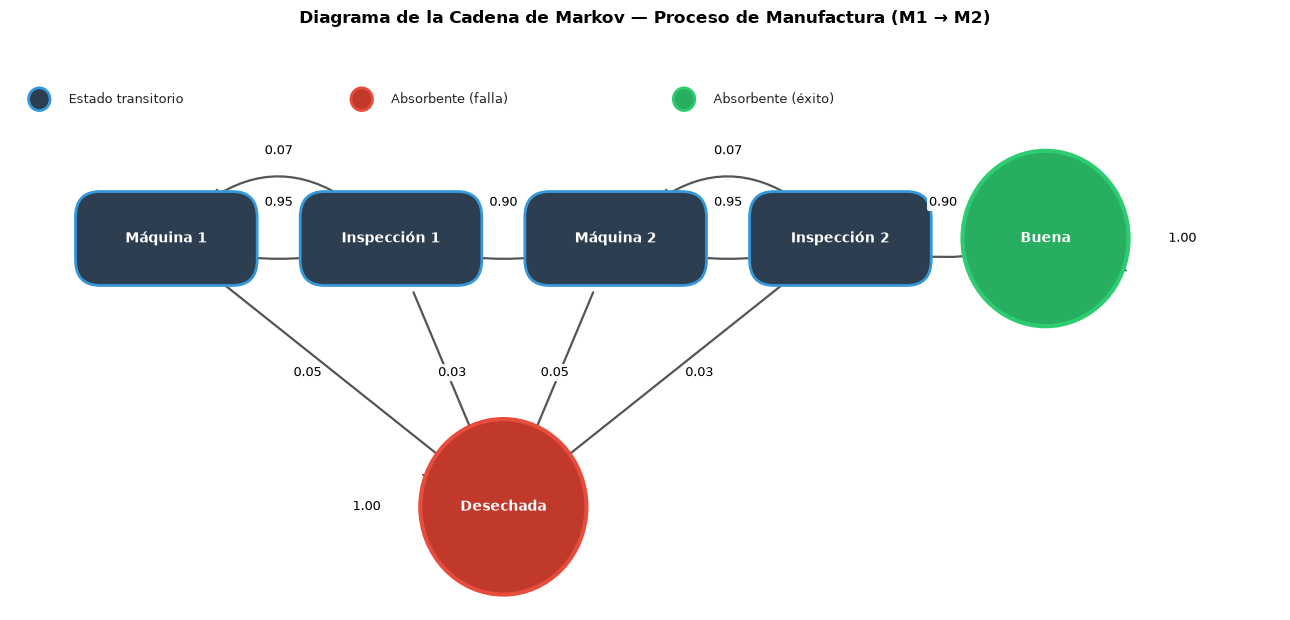

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 6.3))
ax.set_xlim(-1.6, 11.4)
ax.set_ylim(-3.6, 1.9)
ax.axis('off')

COLOR_TRANS_FILL = '#2c3e50'
COLOR_TRANS_EDGE = '#3498db'
COLOR_FALLA_FILL = '#c0392b'
COLOR_FALLA_EDGE = '#e74c3c'
COLOR_EXITO_FILL = '#27ae60'
COLOR_EXITO_EDGE = '#2ecc71'

# Posiciones de los estados (mismo layout que el diagrama Mermaid: graph LR)
pos = {
    'M1': (0, 0),
    'I1': (2.3, 0),
    'M2': (4.6, 0),
    'I2': (6.9, 0),
    'B':  (9.0, 0),
    'D':  (3.45, -2.6),
}
labels = {
    'M1': 'Máquina 1',
    'I1': 'Inspección 1',
    'M2': 'Máquina 2',
    'I2': 'Inspección 2',
    'B':  'Buena',
    'D':  'Desechada',
}

# Estados transitorios: rectángulos redondeados
box_w, box_h = 1.7, 0.75
for n in ['M1', 'I1', 'M2', 'I2']:
    x, y = pos[n]
    box = FancyBboxPatch((x - box_w / 2, y - box_h / 2), box_w, box_h,
                          boxstyle="round,pad=0.08,rounding_size=0.25",
                          linewidth=2, edgecolor=COLOR_TRANS_EDGE, facecolor=COLOR_TRANS_FILL,
                          zorder=3)
    ax.add_patch(box)
    ax.text(x, y, labels[n], ha='center', va='center', color='white',
             fontsize=10, fontweight='bold', zorder=4)

# Estados absorbentes: círculos
for n, fill, edge in [('D', COLOR_FALLA_FILL, COLOR_FALLA_EDGE), ('B', COLOR_EXITO_FILL, COLOR_EXITO_EDGE)]:
    x, y = pos[n]
    circ = Circle((x, y), 0.85, linewidth=3, edgecolor=edge, facecolor=fill, zorder=3)
    ax.add_patch(circ)
    ax.text(x, y, labels[n], ha='center', va='center', color='white',
             fontsize=10, fontweight='bold', zorder=4)


def edge_straight(a, b, label, rad=0.0, color='#555555', lw=1.6, label_offset=(0, 0.18)):
    xa, ya = pos[a]
    xb, yb = pos[b]
    arrow = FancyArrowPatch((xa, ya), (xb, yb), connectionstyle=f"arc3,rad={rad}",
                             arrowstyle='-|>', mutation_scale=16, linewidth=lw,
                             color=color, shrinkA=42, shrinkB=42, zorder=2)
    ax.add_patch(arrow)
    mx, my = (xa + xb) / 2, (ya + yb) / 2
    ax.text(mx + label_offset[0], my + label_offset[1], label, ha='center', va='center',
             fontsize=9.5, color='black',
             bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.9), zorder=5)


# Flujo principal (avance tras pasar máquina / inspección)
edge_straight('M1', 'I1', '0.95', rad=0.18, label_offset=(0, 0.35))
edge_straight('I1', 'M2', '0.90', rad=0.18, label_offset=(0, 0.35))
edge_straight('M2', 'I2', '0.95', rad=0.18, label_offset=(0, 0.35))
edge_straight('I2', 'B',  '0.90', rad=0.18, label_offset=(0, 0.35))

# Retrabajo: la inspección devuelve la pieza a la misma máquina
edge_straight('I1', 'M1', '0.07', rad=0.55, label_offset=(0, 0.85))
edge_straight('I2', 'M2', '0.07', rad=0.55, label_offset=(0, 0.85))

# Descarte antes de inspección (M1, M2) y después de inspección (I1, I2)
edge_straight('M1', 'D', '0.05', rad=0.0, label_offset=(-0.28, 0))
edge_straight('I1', 'D', '0.03', rad=0.0, label_offset=(0.05, 0))
edge_straight('M2', 'D', '0.05', rad=0.0, label_offset=(-0.05, 0))
edge_straight('I2', 'D', '0.03', rad=0.0, label_offset=(0.28, 0))

# Lazos de absorción (a los costados, para no salir del lienzo)
r_abs = 0.85
loopD = FancyArrowPatch((pos['D'][0] - r_abs, pos['D'][1] + 0.32),
                         (pos['D'][0] - r_abs, pos['D'][1] - 0.32),
                         connectionstyle="arc3,rad=-1.3", arrowstyle='-|>',
                         mutation_scale=14, linewidth=1.4, color='#555555', zorder=2)
ax.add_patch(loopD)
ax.text(pos['D'][0] - r_abs - 0.55, pos['D'][1], '1.00', ha='center', va='center', fontsize=9, color='black')

loopB = FancyArrowPatch((pos['B'][0] + r_abs, pos['B'][1] - 0.32),
                         (pos['B'][0] + r_abs, pos['B'][1] + 0.32),
                         connectionstyle="arc3,rad=-1.3", arrowstyle='-|>',
                         mutation_scale=14, linewidth=1.4, color='#555555', zorder=2)
ax.add_patch(loopB)
ax.text(pos['B'][0] + r_abs + 0.55, pos['B'][1], '1.00', ha='center', va='center', fontsize=9, color='black')

# Leyenda
legend_items = [
    ('Estado transitorio', COLOR_TRANS_FILL, COLOR_TRANS_EDGE),
    ('Absorbente (falla)', COLOR_FALLA_FILL, COLOR_FALLA_EDGE),
    ('Absorbente (éxito)', COLOR_EXITO_FILL, COLOR_EXITO_EDGE),
]
for i, (text, fill, edge) in enumerate(legend_items):
    ly = 1.35
    lx = -1.3 + i * 3.3
    ax.add_patch(Circle((lx, ly), 0.11, facecolor=fill, edgecolor=edge, linewidth=2, zorder=3))
    ax.text(lx + 0.3, ly, text, va='center', fontsize=9.5, color='#222222')

ax.set_title('Diagrama de la Cadena de Markov — Proceso de Manufactura (M1 → M2)',
              fontsize=12, fontweight='bold', pad=14)

plt.tight_layout()
plt.show()


Resolucion de Ejercicio 4 parte 2: 

Al analizar la presentación de la "Clase 6" y tus notas, es necesario realizar ajustes técnicos sobre la nomenclatura de las matrices y la justificación de los pasos para que la resolución sea estrictamente fiel al marco teórico que están estudiando.

A continuación, desarrollo el problema priorizando el **por qué** matemático y físico detrás de cada ecuación, paso por paso.

## El Principio Matemático: ¿Por qué usamos Cadenas de Markov Absorbentes?

En un sistema de manufactura donde existen lazos de retroalimentación (reprocesos), la trayectoria de una pieza es un proceso estocástico. Este sistema cumple con la **propiedad de Markov**: el estado futuro de la pieza depende únicamente de su estado actual, no de su historial.

Dado que existen estados "terminales" o "absorbentes" de los cuales la pieza no puede salir (ser desechada o terminada), el sistema se clasifica como una **Cadena de Markov Absorbente**. El análisis matricial de este sistema nos permite resolver la serie geométrica infinita de los bucles de reproceso para encontrar probabilidades globales y tiempos de ciclo esperados.

### 4.1. Cadena de Markov y Clasificación de Estados

Para modelar el problema, definimos los estados y analizamos las transiciones basándonos en las reglas del proceso.

**1. Estados Transitorios:**

Son aquellos de los cuales el sistema puede salir, y una vez que lo hace, existe la probabilidad de no volver. Representan las etapas activas de la línea de ensamble:

- **M1**: Máquina 1.
- **I1**: Inspección 1.
- **M2**: Máquina 2.
- **I2**: Inspección 2.

**2. Estados Absorbentes:**

Son estados terminales. Físicamente representan la salida del sistema; una vez alcanzados, la probabilidad de permanecer en ellos es del 100% (matemáticamente, probabilidad = 1).

- **D**: Desecho (Scrap).
- **B**: Buena (Pieza terminada).

*(Nota: en este diagrama no existen estados recurrentes que no sean los absorbentes, ya que toda pieza eventualmente terminará en D o B).*

## 4.2. Matriz de Transición en Forma Canónica

**El por qué:** Para resolver el sistema, debemos ordenar la matriz de transición ubicando primero los estados transitorios y al final los absorbentes. Esto nos permite dividir la matriz $P$ en bloques funcionales, obteniendo lo que se conoce como **Forma Canónica**:

$$
P = \begin{pmatrix} Q & R \\ 0 & I \end{pmatrix}
$$

- $Q$ (Transitorio → Transitorio): Dinámica interna de reprocesos y avances.
- $R$ (Transitorio → Absorbente): Probabilidad de salir del sistema desde una etapa específica.
- $0$ e $I$: Matrices nula e identidad, indicando que de los estados absorbentes no se sale.

Extrayendo las probabilidades de tu enunciado y armando la matriz $6 \times 6$ en el orden (M1, I1, M2, I2, D, B):

$$
P = \left(
\begin{array}{cccc|cc}
0 & 0.95 & 0 & 0 & 0.05 & 0 \\
0.07 & 0 & 0.90 & 0 & 0.03 & 0 \\
0 & 0 & 0 & 0.95 & 0.05 & 0 \\
0 & 0 & 0.07 & 0 & 0.03 & 0.90 \\
\hline
0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 1
\end{array}
\right)
$$

---

## Paso Auxiliar Obligatorio: La Matriz Fundamental ($N$)

Antes de resolver las probabilidades finales, necesitamos aislar y resolver los bucles infinitos generados por el 7% de probabilidad de reproceso.

**El por qué:** La suma de las probabilidades de todas las posibles visitas a los estados conforma una serie de potencias $I + Q + Q^2 + Q^3 \ldots$ que converge algebraicamente en la **Matriz Fundamental ($N$)**.

Cada elemento $N_{ij}$ representa el número esperado de veces que el sistema visitará el estado $j$ antes de ser absorbido, habiendo comenzado en el estado $i$.

Fórmula para obtenerla:

$$
N = (I - Q)^{-1}
$$

**Paso a paso:**

1. Restamos la submatriz $Q$ de la Identidad $I$:

$$
(I - Q) = \begin{pmatrix}
1 & -0.95 & 0 & 0 \\
-0.07 & 1 & -0.90 & 0 \\
0 & 0 & 1 & -0.95 \\
0 & 0 & -0.07 & 1
\end{pmatrix}
$$

2. Invertimos la matriz resultante para obtener $N$:

$$
N \approx \begin{pmatrix}
1.0712 & 1.0177 & 0.9811 & 0.9321 \\
0.0750 & 1.0712 & 1.0328 & 0.9812 \\
0 & 0 & 1.0712 & 1.0177 \\
0 & 0 & 0.0750 & 1.0712
\end{pmatrix}
$$

## 4.3. Probabilidad de que una pieza que inicia en M1 sea desechada

**El por qué:** Para conocer la probabilidad total de terminar en un estado absorbente específico, multiplicamos la cantidad de veces que visitamos cada etapa (Matriz $N$) por la probabilidad de "caer" en el estado absorbente desde esa etapa (Matriz $R$).

Esto genera la matriz de absorción $B$:

$$
B = N \cdot R
$$

Buscamos empezar en **M1** (Fila 1 de $N$) y terminar en **D** (Columna 1 de $R$):

$$
B_{11} = (N_{11} \cdot R_{11}) + (N_{12} \cdot R_{21}) + (N_{13} \cdot R_{31}) + (N_{14} \cdot R_{41})
$$

$$
B_{11} = (1.0712 \cdot 0.05) + (1.0177 \cdot 0.03) + (0.9811 \cdot 0.05) + (0.9321 \cdot 0.03)
$$

$$
B_{11} \approx 0.0535 + 0.0305 + 0.0490 + 0.0279 = 0.1611
$$

**Respuesta:** Existe un **16.11%** de probabilidades de que una pieza ingresada en M1 termine siendo desechada.

---

## 4.4. Probabilidad de que una pieza de la máquina M2 sea terminada

Aplicamos la misma lógica matricial $B = N \cdot R$. Esta vez evaluamos empezar en **M2** (Fila 3 de $N$) y terminar en **B** (Columna 2 de $R$):

$$
B_{32} = (N_{31} \cdot R_{12}) + (N_{32} \cdot R_{22}) + (N_{33} \cdot R_{32}) + (N_{34} \cdot R_{42})
$$

$$
B_{32} = (0 \cdot 0) + (0 \cdot 0) + (1.0712 \cdot 0) + (1.0177 \cdot 0.90)
$$

$$
B_{32} \approx 0.9159
$$

**Respuesta:** Una pieza que inicia su proceso en M2 tiene un **91.59%** de probabilidades de salir como pieza terminada (Buena).

---

## 4.5. Tiempo esperado de procesamiento iniciando en M1

**El por qué:** Si multiplicamos el número de veces promedio que una pieza visita cada estación (dado por la Matriz Fundamental $N$) por el tiempo puntual que demora cada una de esas visitas, obtenemos el tiempo total acumulado esperado antes de la absorción.

Definimos el vector columna de tiempos $\tau$ para los estados (M1, I1, M2, I2):

$$
\tau = \begin{pmatrix} 20 \\ 5 \\ 30 \\ 7 \end{pmatrix}
$$

Calculamos el tiempo medio $T$ mediante la ecuación $T = N \cdot \tau$. Evaluamos para la fila 1 (inicio en M1):

$$
T_1 = (N_{11} \cdot \tau_1) + (N_{12} \cdot \tau_2) + (N_{13} \cdot \tau_3) + (N_{14} \cdot \tau_4)
$$

$$
T_1 = (1.0712 \cdot 20) + (1.0177 \cdot 5) + (0.9811 \cdot 30) + (0.9321 \cdot 7)
$$

$$
T_1 \approx 21.424 + 5.088 + 29.433 + 6.524 = 62.47
$$

**Respuesta:** El tiempo esperado de procesamiento para una pieza que ingresa en la máquina 1 es de **62.47 minutos**. Analíticamente, este valor es superior a la simple suma de los tiempos nominales $(20 + 5 + 30 + 7 = 62)$ porque el sistema absorbe la penalización temporal de los bucles de reproceso causados por los rechazos en las inspecciones.

## Ejercicios de implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

5. Diseñar un controlador difuso para jugar al Pong. El juego consiste en una pelota que rebota dentro de una cancha rectangular y palas controladas por el sistema difuso o el jugador. El entorno debe cumplir las siguientes reglas:

* La cancha posee dimensiones fijas.
* La pelota rebota en los bordes superior e inferior. Los bordes laterales funcionan como un arco y cuando la pelota atraviesa un borde suma un punto al lado opuesto, sin importar quién toca la pelota por última vez.
* La velocidad de la pelota debe ir incrementando con cada rebot en una pala o pared. Marcar un gol restablece los valores de velocidad a su configuración original.
* Cada pala únicamente puede desplazarse verticalmente y con velocidad fija durante toda la ejecución.
* Cada pala tiene una altura fija.
* Es necesario definir un puntaje mínimo que de el juego por finalizado.

La variable de salida sobre la que actúa el controlador es la **velocidad de la pala**. Las variables de entrada quedan a definir por ustedes.

Como mínimo deben hacer un modo de "un jugador" (ustedes vs. el agente), pero pueden incorporar un modo de "dos jugadores" que consista en utilizar dos agentes con variaciones en las reglas del motor de inferencia, mecanismos de fuzzificación o desfuzzificación de la información y/o las funciones de pertenencia de cada grupo.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)
